\# Assignment

**Name:** Abhay  
**ID:** 08117702023  
**Class:** BCA V-B  
**Assistant Professor:** Mamta Madan  

---

## Questions based on Voting ensemble

**Instructor:** Mamta Madan  
**Points:** 100  
**Due Date:30 september**

---  

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
# Load & Preprocess Data
iris = load_iris()
X, y = iris.data, iris.target

In [ ]:
# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
log_clf = LogisticRegression(max_iter=200, random_state=42)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
knn_clf = KNeighborsClassifier(n_neighbors=5)

In [ ]:
ensemble_clf = VotingClassifier(
    estimators=[('lr', log_clf), ('rf', rf_clf), ('knn', knn_clf)],
    voting='hard'
)


In [ ]:
ensemble_clf.fit(X_train, y_train)
y_pred = ensemble_clf.predict(X_test)

In [ ]:
# Train & Evaluate
# ------------------
models = {
    "Logistic Regression": log_clf,
    "Random Forest": rf_clf,
    "KNN": knn_clf,
    "Ensemble": ensemble_clf
}


In [ ]:
accuracies = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies[name] = acc
    if name == "Ensemble":
        cm = confusion_matrix(y_test, y_pred)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Ensemble Classifier Predictions:", y_pred)
print("True Labels:", y_test)
print(f"Ensemble Classifier Accuracy: {accuracy * 100:.2f}%")

Ensemble Classifier Predictions: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
True Labels: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Ensemble Classifier Accuracy: 100.00%


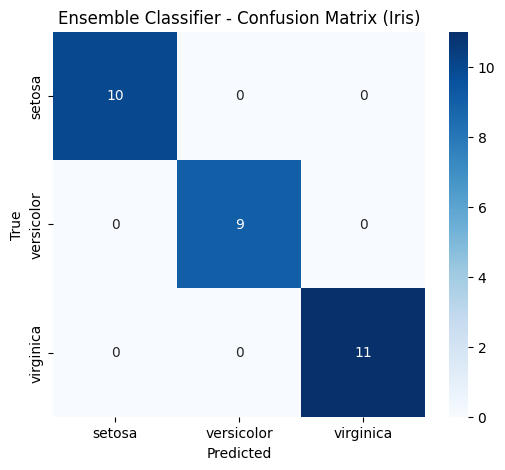

In [ ]:
# Plot Confusion Matrix for Ensemble
# ------------------
plt.figure(figsize=(6, 5))
class_names = iris.target_names # Define class_names here
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Ensemble Classifier - Confusion Matrix (Iris)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

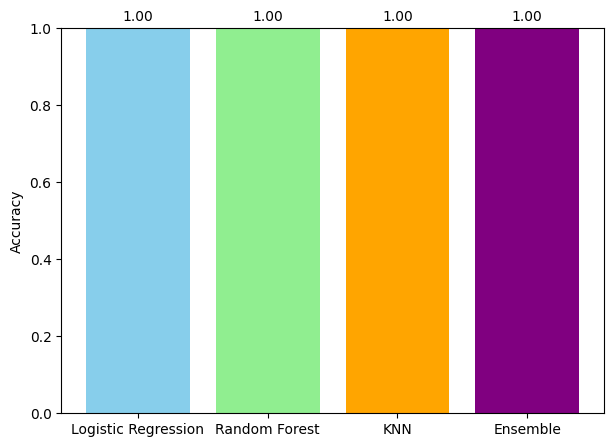

In [ ]:
plt.figure(figsize=(7, 5))
plt.bar(accuracies.keys(), accuracies.values(), color=['skyblue', 'lightgreen', 'orange', 'purple'])
plt.ylabel("Accuracy")
plt.ylim(0, 1)
for i, acc in enumerate(accuracies.values()):
    plt.text(i, acc + 0.02, f"{acc:.2f}", ha='center')
plt.show()